
<h1 style="color:#ffffff; background-color:#173F5F; text-align:center; font-weight:bold; padding:16px 10px; border-radius:8px; margin-bottom:6px;">
Day 4 — Attention &amp; Transformers
</h1>
<h3 style="color:#20639B; text-align:center; font-weight:bold; margin-top:0;">
Self-Attention, Pre-trained Transformers, Hugging Face &amp; IMDb Sentiment Continuation
</h3>



<a id="toc"></a>
<h2 style="color:#F6D55C; background-color:#20639B; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">Table of Contents</h2>

<div style="border:1px solid #ccc; padding:15px 25px; border-radius:6px;">
<ul style="font-weight:bold; line-height:1.9; color:#1F2937;">
<li><a href="#section0">0. Setup — Imports, Runtime & Folder Structure</a></li>
<li><a href="#section1">1. Day 4 Roadmap & Connection to Day 3</a></li>
<li><a href="#section2">2. Why Move Beyond RNN/LSTM?</a></li>
<li><a href="#section3">3. Attention & Self-Attention</a></li>
<li><a href="#section4">4. Transformer Architecture & Positional Information</a></li>
<li><a href="#section5">5. Pre-trained Transformers — BERT, DistilBERT & GPT-2</a></li>
<li><a href="#section6">6. Hugging Face & Selected Model</a></li>
<li><a href="#section7">7. Continue Day 3 — Load the Same IMDb Dataset</a></li>
<li><a href="#section8">8. Transformer Inference on Real IMDb Reviews</a></li>
<li><a href="#section9">9. Context Stress Test</a></li>
<li><a href="#section10">10. Transformer Evaluation</a></li>
<li><a href="#section11">11. Self-Attention Visualization</a></li>
<li><a href="#section12">12. Day 3 vs Day 4 Model Comparison</a></li>
<li><a href="#section13">13. RNN/LSTM vs Transformer</a></li>
<li><a href="#section14">14. Implementation Decisions & Limitations</a></li>
<li><a href="#section15">15. What I Learned Today</a></li>
</ul>
</div>



<a id="section0"></a>
<h2 style="color:#F6D55C; background-color:#20639B; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">0. Setup — Imports, Runtime &amp; Folder Structure</h2>

<div style="border-left:5px solid #3CAEA3; background-color:#E8F7F5; padding:10px 15px; margin:10px 0; border-radius:4px; color:#245B55;">
<b>Important path:</b> Day 4 does <u>not</u> create a second IMDb dataset.  
It reuses the dataset that already exists inside <code>Day 3/dataset/imdb.npz</code>.
</div>

The notebook is designed for this project structure:

<pre style="background-color:#F7F9FA; border:1px solid #D9E2E7; padding:14px; border-radius:6px; color:#243746;">
Week 7/
├── Day 3/
│   ├── dataset/
│   │   └── imdb.npz
│   ├── Day3.ipynb
│   └── README.md
│
└── Day 4/
    ├── Day 4.pdf
    ├── Day4.ipynb
    └── README.md
</pre>

<div style="border-left:5px solid #F6D55C; background-color:#FFF8DB; padding:10px 15px; margin:10px 0; border-radius:4px; color:#665314;">
<b>First-run requirement:</b> The pre-trained Transformer itself must be downloaded from Hugging Face once.
After it is cached, later runs can reuse the local model files.
</div>


In [1]:
# Run once if Transformers / PyTorch are not installed.
# In Google Colab you can uncomment the next line:
# %pip install -q transformers torch scikit-learn

import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

import torch
from transformers import pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DEVICE = 0 if torch.cuda.is_available() else -1

print("TensorFlow version:", tf.__version__)
print("PyTorch version    :", torch.__version__)
print("Transformer device :", "GPU" if DEVICE == 0 else "CPU")


TensorFlow version: 2.21.0
PyTorch version    : 2.14.0+cpu
Transformer device : CPU


In [2]:
from pathlib import Path

CURRENT_DIR = Path.cwd()

IMDB_PATH = (
    CURRENT_DIR.parent
    / "Day 3"
    / "dataset"
    / "imdb.npz"
)

if not IMDB_PATH.exists():
    raise FileNotFoundError(
        f"IMDb dataset was not found at:\n{IMDB_PATH}"
    )



<a id="section1"></a>
<h2 style="color:#F6D55C; background-color:#20639B; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">1. Day 4 Roadmap &amp; Connection to Day 3</h2>

<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr>
<th style="background-color:#20639B; color:#F6D55C; padding:8px; text-align:left;">Day 4 Requirement</th>
<th style="background-color:#20639B; color:#F6D55C; padding:8px; text-align:left;">How It Is Applied Here</th>
</tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">RNN/LSTM limitation</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Connect Day 3 step-by-step memory to the need for attention</td></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Attention mechanism</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Explain self-attention and inspect real attention weights</td></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Transformer architecture</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Understand attention, feed-forward blocks, and positional information</td></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Pre-trained models</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Compare BERT, DistilBERT, and GPT-2 conceptually</td></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Hugging Face</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Load a ready DistilBERT sentiment model</td></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Hands-on text task</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Apply DistilBERT to the same IMDb sentiment task used in Day 3</td></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Compare architectures</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Compare Day 3 results with Day 4 Transformer performance</td></tr>
</table>
</div>

<br>

<div style="display:flex; flex-wrap:wrap; align-items:center; gap:8px; justify-content:center; margin:14px 0;">
<div style="background:#EAF2F8; border:1px solid #B8D4E8; padding:10px 14px; border-radius:10px; font-weight:bold; color:#173F5F;">IMDb Review</div>
<div style="font-size:22px; color:#20639B;">↓</div>
<div style="background:#E8F7F5; border:1px solid #B6E2DC; padding:10px 14px; border-radius:10px; font-weight:bold; color:#245B55;">Tokenizer</div>
<div style="font-size:22px; color:#20639B;">↓</div>
<div style="background:#FFF8DB; border:1px solid #F1D978; padding:10px 14px; border-radius:10px; font-weight:bold; color:#665314;">DistilBERT</div>
<div style="font-size:22px; color:#20639B;">↓</div>
<div style="background:#FDEDE8; border:1px solid #F2B6A5; padding:10px 14px; border-radius:10px; font-weight:bold; color:#7A3E2E;">Positive / Negative</div>
</div>



<a id="section2"></a>
<h2 style="color:#F6D55C; background-color:#20639B; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">2. Why Move Beyond RNN/LSTM?</h2>

<h3 style="color:#F6D55C; font-weight:bold; background-color:#173F5F; display:inline-block; padding:4px 10px; border-radius:6px;">2.1 Day 3 idea</h3>

RNNs and LSTMs process sequential data <b>step by step</b>.  
The LSTM improves memory using gates, but the sequence is still recurrent:

<div style="border-left:5px solid #20639B; background-color:#EAF2F8; padding:10px 15px; margin:10px 0; border-radius:4px; color:#173F5F;">
<b>RNN/LSTM flow:</b><br>
word 1 → word 2 → word 3 → word 4 → ... → final representation
</div>

<h3 style="color:#F6D55C; font-weight:bold; background-color:#173F5F; display:inline-block; padding:4px 10px; border-radius:6px;">2.2 Limitation</h3>

Because later steps depend on earlier recurrent steps, RNN/LSTM processing is difficult to parallelize.
Very distant relationships must also travel through many recurrent updates.

<div style="border-left:5px solid #ED553B; background-color:#FDEDE8; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7A3E2E;">
<b>Bridge to Day 4:</b> The Transformer removes recurrence and lets positions interact directly through
<b>self-attention</b>.
</div>



<a id="section3"></a>
<h2 style="color:#F6D55C; background-color:#20639B; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">3. Attention &amp; Self-Attention</h2>

<h3 style="color:#F6D55C; font-weight:bold; background-color:#173F5F; display:inline-block; padding:4px 10px; border-radius:6px;">3.1 Attention</h3>

Attention answers:

> <b>Which other elements are most relevant to the element I am processing?</b>

For the sentence:

<pre style="background:#F7F9FA; border:1px solid #D9E2E7; padding:12px; border-radius:6px;color:black;">
The movie was long, but it was interesting.
</pre>

the token <code>it</code> may need to focus strongly on <code>movie</code>.

<h3 style="color:#F6D55C; font-weight:bold; background-color:#173F5F; display:inline-block; padding:4px 10px; border-radius:6px;">3.2 Self-Attention</h3>

In <b>self-attention</b>, tokens inside the same sequence attend to each other.

<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr><th style="background-color:#20639B; color:#F6D55C; padding:8px; text-align:left;">Part</th><th style="background-color:#20639B; color:#F6D55C; padding:8px; text-align:left;">Intuition</th></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;"><b>Query (Q)</b></td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">What information am I looking for?</td></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;"><b>Key (K)</b></td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">What kind of information do I contain?</td></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;"><b>Value (V)</b></td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">What information should I contribute if I am relevant?</td></tr>
</table>
</div>

<div style="border-left:5px solid #3CAEA3; background-color:#E8F7F5; padding:10px 15px; margin:10px 0; border-radius:4px; color:#245B55;">
<b>Concept flow:</b> Query → compare with Keys → attention scores → weighted Values → contextual representation
</div>


In [3]:
# Small hand-made example for intuition only.
# These are illustrative weights, NOT values extracted from DistilBERT.

words = ["The", "movie", "was", "long", "but", "it", "was", "interesting"]
illustrative_attention = [0.03, 0.55, 0.04, 0.07, 0.05, 0.18, 0.03, 0.05]

attention_demo = pd.DataFrame({
    "Word": words,
    "Illustrative attention to 'it'": illustrative_attention,
}).sort_values("Illustrative attention to 'it'", ascending=False)

attention_demo


,Word,Illustrative attention to 'it'
1,movie,0.55
5,it,0.18
3,long,0.07
4,but,0.05
7,interesting,0.05
2,was,0.04
0,The,0.03
6,was,0.03



<a id="section4"></a>
<h2 style="color:#F6D55C; background-color:#20639B; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">4. Transformer Architecture &amp; Positional Information</h2>

<div style="display:flex; flex-wrap:wrap; align-items:center; gap:8px; justify-content:center; margin:14px 0;">
<div style="background:#EAF2F8; padding:10px 14px; border-radius:10px; border:1px solid #B8D4E8;color:black; "><b>Tokens</b></div>
<div style="font-size:22px;">+</div>
<div style="background:#FFF8DB; padding:10px 14px; border-radius:10px; border:1px solid #F1D978;color:black; "><b>Position</b></div>
<div style="font-size:22px;">→</div>
<div style="background:#E8F7F5; padding:10px 14px; border-radius:10px; border:1px solid #B6E2DC;color:black; "><b>Multi-Head Self-Attention</b></div>
<div style="font-size:22px;">→</div>
<div style="background:#FDEDE8; padding:10px 14px; border-radius:10px; border:1px solid #F2B6A5;color:black; "><b>Feed-Forward Layers</b></div>
</div>

<h3 style="color:#F6D55C; font-weight:bold; background-color:#173F5F; display:inline-block; padding:4px 10px; border-radius:6px;">4.1 Why positional information?</h3>

The Transformer has no recurrent step that automatically tells it which token came first.
So token position must be represented explicitly.

<pre style="background:#F7F9FA; border:1px solid #D9E2E7; padding:12px; border-radius:6px;">
Dog bites man  ≠  Man bites dog
</pre>

<h3 style="color:#F6D55C; font-weight:bold; background-color:#173F5F; display:inline-block; padding:4px 10px; border-radius:6px;">4.2 Multi-Head Attention</h3>

Instead of using one attention pattern, several attention heads can learn different relationships at the same time.
One head may respond strongly to negation while another may focus on longer semantic relationships.



<a id="section5"></a>
<h2 style="color:#F6D55C; background-color:#20639B; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">5. Pre-trained Transformers — BERT, DistilBERT &amp; GPT-2</h2>

<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr>
<th style="background-color:#20639B; color:#F6D55C; padding:8px; text-align:left;">Model</th>
<th style="background-color:#20639B; color:#F6D55C; padding:8px; text-align:left;">Architecture Style</th>
<th style="background-color:#20639B; color:#F6D55C; padding:8px; text-align:left;">Main Strength</th>
<th style="background-color:#20639B; color:#F6D55C; padding:8px; text-align:left;">Simple Idea</th>
</tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;"><b>BERT</b></td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Encoder-based</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Text understanding / classification</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Understand context</td></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;"><b>DistilBERT</b></td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Smaller distilled BERT</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">BERT-like understanding with lower compute</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Understand efficiently</td></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;"><b>GPT-2</b></td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Decoder-based autoregressive model</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Next-token prediction / generation</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Generate text</td></tr>
</table>
</div>

<div style="border-left:5px solid #F6D55C; background-color:#FFF8DB; padding:10px 15px; margin:10px 0; border-radius:4px; color:#665314;">
<b>Our choice:</b> DistilBERT is appropriate here because the Day 3 task is sentiment <b>classification</b>,
not free-form text generation.
</div>



<a id="section6"></a>
<h2 style="color:#F6D55C; background-color:#20639B; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">6. Hugging Face &amp; Selected Model</h2>

<b>Hugging Face</b> provides the model hub and the <code>transformers</code> library.
It lets us download and use ready Transformer checkpoints without implementing the Transformer from scratch.

<h3 style="color:#F6D55C; font-weight:bold; background-color:#173F5F; display:inline-block; padding:4px 10px; border-radius:6px;">6.1 Do we need ready models?</h3>

<div style="border-left:5px solid #3CAEA3; background-color:#E8F7F5; padding:10px 15px; margin:10px 0; border-radius:4px; color:#245B55;">
<b>Yes — but only one model is needed for the practical lab.</b><br>
We do not need to download BERT, DistilBERT, and GPT-2 together.
We use one ready DistilBERT model and explain the other architectures conceptually.
</div>

Selected checkpoint:

<pre style="background:#F7F9FA; border:1px solid #D9E2E7; padding:12px; border-radius:6px;">
distilbert-base-uncased-finetuned-sst-2-english
</pre>

It is already:
<ol style="line-height:1.8;">
<li><b>pre-trained</b> to learn general language representations, and</li>
<li><b>fine-tuned</b> for English positive/negative sentiment classification.</li>
</ol>


In [4]:
MODEL_NAME = "distilbert-base-uncased-finetuned-sst-2-english"

sentiment_model = pipeline(
    "sentiment-analysis",
    model=MODEL_NAME,
    tokenizer=MODEL_NAME,
    device=DEVICE,
)

print("Ready model loaded:", MODEL_NAME)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Ready model loaded: distilbert-base-uncased-finetuned-sst-2-english


In [5]:
# First sanity check
sample_texts = [
    "This internship is excellent and very useful.",
    "This movie was boring and disappointing.",
    "The acting was good, but I did not enjoy the story."
]

sample_predictions = sentiment_model(
    sample_texts,
    truncation=True,
    max_length=512,
)

sample_results = pd.DataFrame({
    "Text": sample_texts,
    "Prediction": [p["label"] for p in sample_predictions],
    "Confidence": [p["score"] for p in sample_predictions],
})

sample_results


,Text,Prediction,Confidence
0,This internship is excellent and very useful.,POSITIVE,0.999858
1,This movie was boring and disappointing.,NEGATIVE,0.999784
2,"The acting was good, but I did not enjoy the s...",NEGATIVE,0.991440



<a id="section7"></a>
<h2 style="color:#F6D55C; background-color:#20639B; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">7. Continue Day 3 — Load the Same IMDb Dataset</h2>

<div style="border-left:5px solid #20639B; background-color:#EAF2F8; padding:10px 15px; margin:10px 0; border-radius:4px; color:#173F5F;">
<b>Why this is better than a separate Day 4 dataset:</b> Using the same IMDb sentiment task makes the architecture
comparison meaningful. Day 3 tests recurrent models; Day 4 tests a pre-trained Transformer on the same problem.
</div>


In [6]:
# Load the exact IMDb arrays saved by Day 3.
local_data = np.load(IMDB_PATH, allow_pickle=True)

x_train_raw = local_data["x_train"].tolist()
y_train = local_data["y_train"].astype(np.int32)

x_test_raw = local_data["x_test"].tolist()
y_test = local_data["y_test"].astype(np.int32)

print("Training reviews:", len(x_train_raw))
print("Test reviews    :", len(x_test_raw))
print("Test negatives  :", int((y_test == 0).sum()))
print("Test positives  :", int((y_test == 1).sum()))


Training reviews: 25000
Test reviews    : 25000
Test negatives  : 12500
Test positives  : 12500



<h3 style="color:#F6D55C; font-weight:bold; background-color:#173F5F; display:inline-block; padding:4px 10px; border-radius:6px;">7.1 Convert Day 3 token IDs back to readable text</h3>

Day 3 stores IMDb reviews as integer sequences.  
DistilBERT expects text, so we reconstruct readable review text using the IMDb word index.

<div style="border-left:5px solid #ED553B; background-color:#FDEDE8; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7A3E2E;">
<b>Important:</b> This reconstructed text is approximate. The original Keras sequences contain special tokens,
so the decoded version is suitable for this learning experiment but is not identical to the original raw review text.
</div>


In [7]:
# Keras may download the small IMDb word-index file once if it is not cached.
word_index = keras.datasets.imdb.get_word_index()

reverse_word_index = {index + 3: word for word, index in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

SPECIAL_TOKENS = {"<PAD>", "<START>", "<UNK>", "<UNUSED>"}

def decode_review(token_ids):
    words = [
        reverse_word_index.get(int(token_id), "")
        for token_id in token_ids
    ]
    words = [word for word in words if word and word not in SPECIAL_TOKENS]
    return " ".join(words)

preview_index = 0
preview_text = decode_review(x_test_raw[preview_index])

print("True sentiment:", "POSITIVE" if y_test[preview_index] == 1 else "NEGATIVE")
print("\nDecoded review preview:\n")
print(preview_text[:1000])


True sentiment: NEGATIVE

Decoded review preview:

please give this one a miss br br and the rest of the cast rendered terrible performances the show is flat flat flat br br i don't know how michael madison could have allowed this one on his plate he almost seemed to know this wasn't going to work out and his performance was quite so all you madison fans give this a miss



<a id="section8"></a>
<h2 style="color:#F6D55C; background-color:#20639B; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">8. Transformer Inference on Real IMDb Reviews</h2>

<h3 style="color:#F6D55C; font-weight:bold; background-color:#173F5F; display:inline-block; padding:4px 10px; border-radius:6px;">8.1 Inference</h3>

<b>Inference</b> means using an already trained model to make predictions on new examples.
We are not training DistilBERT from random weights.

<div style="border-left:5px solid #3CAEA3; background-color:#E8F7F5; padding:10px 15px; margin:10px 0; border-radius:4px; color:#245B55;">
Text → Hugging Face tokenizer → DistilBERT → self-attention → classification head → sentiment label
</div>


In [8]:
# Show predictions for a few real IMDb test reviews.
preview_indices = [0, 1, 2, 3, 4]
preview_reviews = [decode_review(x_test_raw[i]) for i in preview_indices]

preview_outputs = sentiment_model(
    preview_reviews,
    batch_size=5,
    truncation=True,
    max_length=512,
)

real_review_demo = pd.DataFrame({
    "True Label": ["POSITIVE" if y_test[i] == 1 else "NEGATIVE" for i in preview_indices],
    "Prediction": [o["label"] for o in preview_outputs],
    "Confidence": [o["score"] for o in preview_outputs],
    "Review Preview": [t[:180] + "..." for t in preview_reviews],
})

real_review_demo


,True Label,Prediction,Confidence,Review Preview
0,NEGATIVE,NEGATIVE,0.999487,please give this one a miss br br and the rest...
1,POSITIVE,POSITIVE,0.999524,this film requires a lot of patience because i...
2,POSITIVE,POSITIVE,0.954796,many animation buffs consider the great forgot...
3,NEGATIVE,NEGATIVE,0.989843,i generally love this type of movie however th...
4,POSITIVE,POSITIVE,0.999744,like some other people wrote i'm a die hard ma...



<a id="section9"></a>
<h2 style="color:#F6D55C; background-color:#20639B; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">9. Context Stress Test</h2>

This experiment makes the notebook more than a simple <code>pipeline()</code> demo.
We deliberately change a small piece of context and observe whether the model changes its decision.

<div style="border-left:5px solid #F6D55C; background-color:#FFF8DB; padding:10px 15px; margin:10px 0; border-radius:4px; color:#665314;">
<b>Question:</b> Does the model react to negation such as <code>not good</code>, or does it simply react to the word
<code>good</code>?
</div>


In [9]:
context_pairs = [
    ("The movie was good.", "The movie was not good."),
    ("I liked the story.", "I did not like the story."),
    ("The ending was satisfying.", "The ending was not satisfying."),
    ("The acting was excellent.", "The acting was not excellent."),
]

context_sentences = [sentence for pair in context_pairs for sentence in pair]

context_outputs = sentiment_model(
    context_sentences,
    truncation=True,
    max_length=512,
)

context_rows = []
for pair_id, pair in enumerate(context_pairs, start=1):
    for version_id, sentence in enumerate(pair):
        output = context_outputs[(pair_id - 1) * 2 + version_id]
        context_rows.append({
            "Pair": pair_id,
            "Version": "Original" if version_id == 0 else "Negated",
            "Sentence": sentence,
            "Prediction": output["label"],
            "Confidence": output["score"],
        })

context_df = pd.DataFrame(context_rows)
context_df


,Pair,Version,Sentence,Prediction,Confidence
0,1,Original,The movie was good.,POSITIVE,0.999857
1,1,Negated,The movie was not good.,NEGATIVE,0.999773
2,2,Original,I liked the story.,POSITIVE,0.999841
3,2,Negated,I did not like the story.,NEGATIVE,0.995833
4,3,Original,The ending was satisfying.,POSITIVE,0.999872
5,3,Negated,The ending was not satisfying.,NEGATIVE,0.999803
6,4,Original,The acting was excellent.,POSITIVE,0.999853
7,4,Negated,The acting was not excellent.,NEGATIVE,0.999716


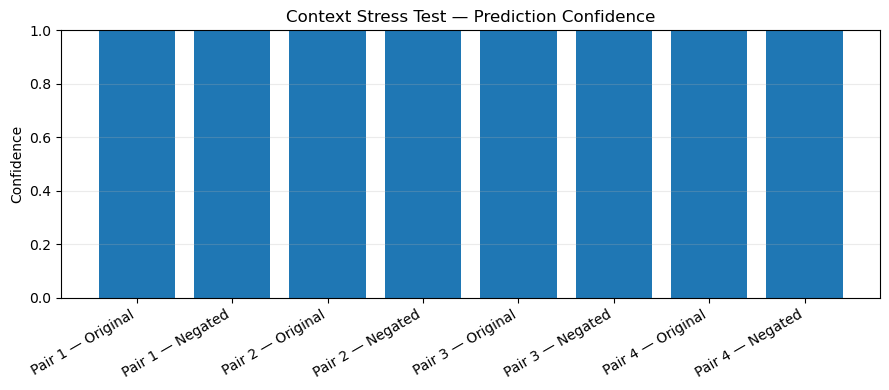

In [10]:
plt.figure(figsize=(9, 4))

labels = (
    "Pair " + context_df["Pair"].astype(str)
    + " — " + context_df["Version"]
)

plt.bar(labels, context_df["Confidence"])
plt.ylabel("Confidence")
plt.title("Context Stress Test — Prediction Confidence")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()



<div style="border-left:5px solid #ED553B; background-color:#FDEDE8; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7A3E2E;">
<b>Interpret carefully:</b> If the label changes after adding negation, that is useful evidence that the model reacts
to context. It does not prove that a single attention head is the only reason for the prediction.
</div>



<a id="section10"></a>
<h2 style="color:#F6D55C; background-color:#20639B; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">10. Transformer Evaluation</h2>

Running all 25,000 IMDb test reviews can be slow on CPU.  
The default experiment therefore evaluates a <b>balanced subset</b>.

<div style="border-left:5px solid #20639B; background-color:#EAF2F8; padding:10px 15px; margin:10px 0; border-radius:4px; color:#173F5F;">
Change <code>EVAL_SAMPLES</code> to <code>25000</code> if you have enough time/GPU and want a direct full-test comparison.
</div>


In [11]:
EVAL_SAMPLES = 1000
BATCH_SIZE = 16

negative_indices = np.flatnonzero(y_test == 0)
positive_indices = np.flatnonzero(y_test == 1)

rng = np.random.default_rng(SEED)
rng.shuffle(negative_indices)
rng.shuffle(positive_indices)

if EVAL_SAMPLES >= len(y_test):
    selected_indices = np.arange(len(y_test))
else:
    n_negative = EVAL_SAMPLES // 2
    n_positive = EVAL_SAMPLES - n_negative

    selected_indices = np.concatenate([
        negative_indices[:n_negative],
        positive_indices[:n_positive],
    ])
    rng.shuffle(selected_indices)

eval_texts = [decode_review(x_test_raw[i]) for i in selected_indices]
eval_labels = y_test[selected_indices]

print("Evaluation samples:", len(eval_texts))
print("Negative:", int((eval_labels == 0).sum()))
print("Positive:", int((eval_labels == 1).sum()))


Evaluation samples: 1000
Negative: 500
Positive: 500


In [12]:
start_time = time.perf_counter()

eval_outputs = sentiment_model(
    eval_texts,
    batch_size=BATCH_SIZE,
    truncation=True,
    max_length=512,
)

inference_time = time.perf_counter() - start_time

predicted_labels = np.array([
    1 if output["label"].upper() == "POSITIVE" else 0
    for output in eval_outputs
])

# Convert the predicted-class confidence into a positive-class score for binary AUC.
positive_scores = np.array([
    output["score"] if output["label"].upper() == "POSITIVE"
    else 1.0 - output["score"]
    for output in eval_outputs
])

transformer_metrics = {
    "Model": "DistilBERT",
    "Evaluation Samples": len(eval_labels),
    "Accuracy": accuracy_score(eval_labels, predicted_labels),
    "Precision": precision_score(eval_labels, predicted_labels),
    "Recall": recall_score(eval_labels, predicted_labels),
    "F1": f1_score(eval_labels, predicted_labels),
    "AUC": roc_auc_score(eval_labels, positive_scores),
    "Inference Time (s)": inference_time,
}

pd.DataFrame([transformer_metrics])


,Model,Evaluation Samples,Accuracy,Precision,Recall,F1,AUC,Inference Time (s)
0,DistilBERT,1000,0.885,0.936508,0.826,0.87779,0.959312,456.67132


              precision    recall  f1-score   support

    Negative     0.8444    0.9440    0.8914       500
    Positive     0.9365    0.8260    0.8778       500

    accuracy                         0.8850      1000
   macro avg     0.8904    0.8850    0.8846      1000
weighted avg     0.8904    0.8850    0.8846      1000



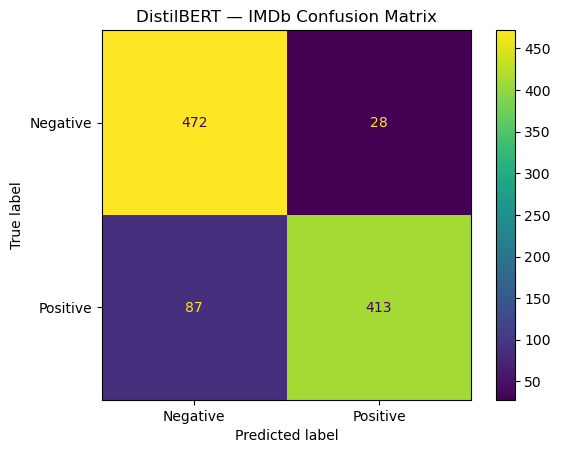

In [13]:
print(classification_report(
    eval_labels,
    predicted_labels,
    target_names=["Negative", "Positive"],
    digits=4,
))

cm = confusion_matrix(eval_labels, predicted_labels)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"],
).plot(values_format="d")

plt.title("DistilBERT — IMDb Confusion Matrix")
plt.show()



<a id="section11"></a>
<h2 style="color:#F6D55C; background-color:#20639B; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">11. Self-Attention Visualization</h2>

This is the feature that makes the practical work stand out:
we inspect attention weights from the same DistilBERT checkpoint instead of only showing the final label.

<div style="border-left:5px solid #3CAEA3; background-color:#E8F7F5; padding:10px 15px; margin:10px 0; border-radius:4px; color:#245B55;">
<b>Goal:</b> connect the theoretical idea of self-attention with an actual token-to-token attention matrix.
</div>


In [14]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

attention_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    attn_implementation="eager"
)

attention_device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

attention_model.to(attention_device)
attention_model.eval()

attention_text = (
    "The movie was not good, "
    "but the ending was surprisingly excellent."
)

encoded = tokenizer(
    attention_text,
    return_tensors="pt",
    truncation=True,
    max_length=128
)

encoded = {
    key: value.to(attention_device)
    for key, value in encoded.items()
}

with torch.no_grad():
    attention_output = attention_model(
        **encoded,
        output_attentions=True,
        return_dict=True
    )

tokens = tokenizer.convert_ids_to_tokens(
    encoded["input_ids"][0].detach().cpu().tolist()
)

print("Number of attention layers:", len(attention_output.attentions))

last_layer_attention = (
    attention_output.attentions[-1][0]
    .detach()
    .cpu()
)

average_attention = (
    last_layer_attention
    .mean(dim=0)
    .numpy()
)

print("Tokens:")
print(tokens)

print("\nAttention matrix shape:")
print(average_attention.shape)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Number of attention layers: 6
Tokens:
['[CLS]', 'the', 'movie', 'was', 'not', 'good', ',', 'but', 'the', 'ending', 'was', 'surprisingly', 'excellent', '.', '[SEP]']

Attention matrix shape:
(15, 15)


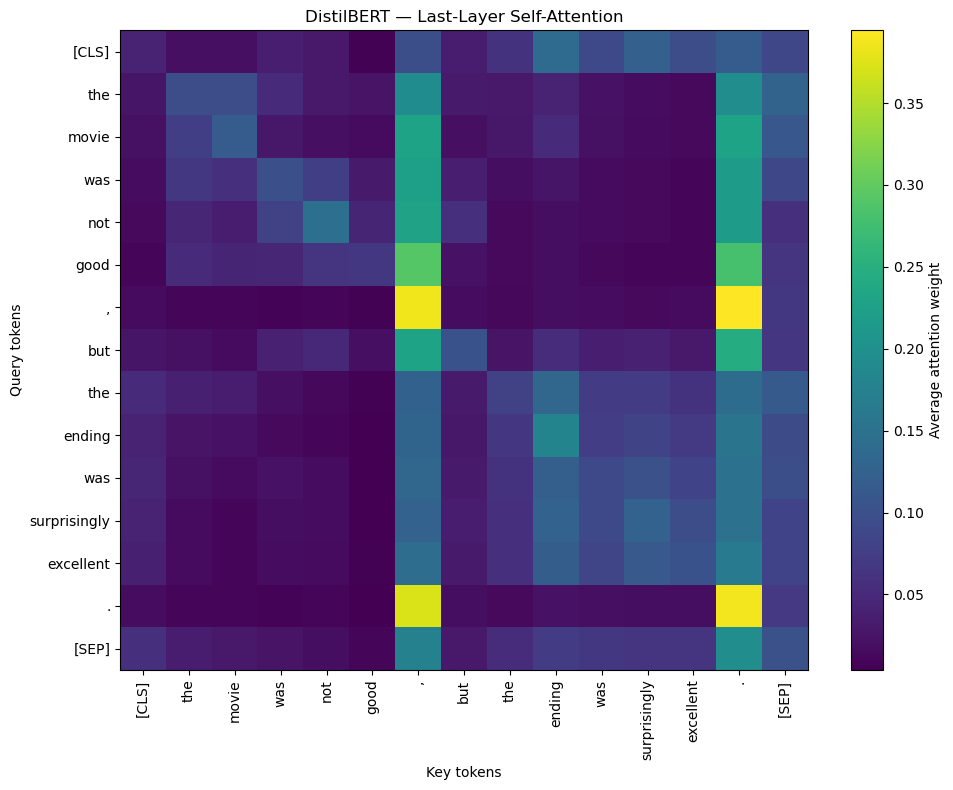

In [15]:
plt.figure(figsize=(10, 8))
plt.imshow(average_attention, aspect="auto")
plt.colorbar(label="Average attention weight")
plt.xticks(range(len(tokens)), tokens, rotation=90)
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("Key tokens")
plt.ylabel("Query tokens")
plt.title("DistilBERT — Last-Layer Self-Attention")
plt.tight_layout()
plt.show()



<div style="border-left:5px solid #F6D55C; background-color:#FFF8DB; padding:10px 15px; margin:10px 0; border-radius:4px; color:#665314;">
<b>How to explain the heatmap:</b> Each row is a query token and each column is a token it can attend to.
The values show relative attention strength after averaging the heads in the final layer.
This is an inspection tool, not a complete explanation of the model's reasoning.
</div>



<a id="section12"></a>
<h2 style="color:#F6D55C; background-color:#20639B; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">12. Day 3 vs Day 4 Model Comparison</h2>

The Day 3 notebook recorded the following full-test results:

<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr>
<th style="background-color:#20639B; color:#F6D55C; padding:8px; text-align:left;">Model</th>
<th style="background-color:#20639B; color:#F6D55C; padding:8px; text-align:left;">Best Validation Accuracy</th>
<th style="background-color:#20639B; color:#F6D55C; padding:8px; text-align:left;">Test Accuracy</th>
<th style="background-color:#20639B; color:#F6D55C; padding:8px; text-align:left;">Test AUC</th>
</tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Non-Sequential Baseline</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">0.8790</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">0.86172</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">0.938281</td></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">LSTM</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">0.8584</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">0.84380</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">0.923725</td></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Simple RNN</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">0.7558</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">0.71920</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">0.786096</td></tr>
</table>
</div>

<div style="border-left:5px solid #ED553B; background-color:#FDEDE8; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7A3E2E;">
<b>Fair-comparison warning:</b> Day 3 results above used the full IMDb test set.
If Day 4 is evaluated on only 1,000 reviews, do not present the numbers as a perfectly equal benchmark.
Run all 25,000 reviews for the fairest direct comparison.
</div>


In [16]:
day3_results = pd.DataFrame([
    {
        "Model": "Non-Sequential Baseline",
        "Accuracy": 0.86172,
        "AUC": 0.938281,
        "Evaluation Samples": 25000,
    },
    {
        "Model": "LSTM",
        "Accuracy": 0.84380,
        "AUC": 0.923725,
        "Evaluation Samples": 25000,
    },
    {
        "Model": "Simple RNN",
        "Accuracy": 0.71920,
        "AUC": 0.786096,
        "Evaluation Samples": 25000,
    },
])

day4_result = pd.DataFrame([{
    "Model": "DistilBERT",
    "Accuracy": transformer_metrics["Accuracy"],
    "AUC": transformer_metrics["AUC"],
    "Evaluation Samples": transformer_metrics["Evaluation Samples"],
}])

comparison = pd.concat([day3_results, day4_result], ignore_index=True)
comparison


,Model,Accuracy,AUC,Evaluation Samples
0,Non-Sequential Baseline,0.86172,0.938281,25000
1,LSTM,0.84380,0.923725,25000
2,Simple RNN,0.71920,0.786096,25000
3,DistilBERT,0.88500,0.959312,1000


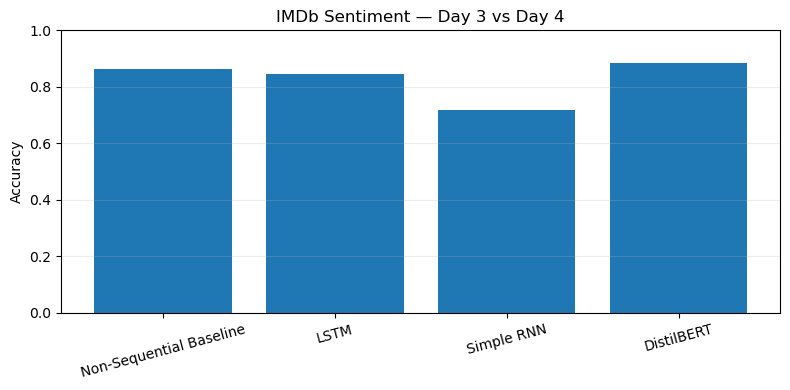

In [17]:
plt.figure(figsize=(8, 4))
plt.bar(comparison["Model"], comparison["Accuracy"])
plt.ylabel("Accuracy")
plt.title("IMDb Sentiment — Day 3 vs Day 4")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()



<a id="section13"></a>
<h2 style="color:#F6D55C; background-color:#20639B; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">13. RNN/LSTM vs Transformer</h2>

<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr>
<th style="background-color:#20639B; color:#F6D55C; padding:8px; text-align:left;">Feature</th>
<th style="background-color:#20639B; color:#F6D55C; padding:8px; text-align:left;">RNN / LSTM</th>
<th style="background-color:#20639B; color:#F6D55C; padding:8px; text-align:left;">Transformer</th>
</tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Processing</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Step by step</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Positions can be processed much more in parallel</td></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Main mechanism</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Recurrent hidden state; LSTM adds gated memory</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Self-attention</td></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Distant relationships</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Information travels through recurrent updates</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Positions can interact directly</td></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Order information</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Naturally follows sequence order</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Position information is added explicitly</td></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Parallelism</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Limited</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Much stronger</td></tr>
</table>
</div>

<div style="border-left:5px solid #20639B; background-color:#EAF2F8; padding:10px 15px; margin:10px 0; border-radius:4px; color:#173F5F;">
<b>Key sentence:</b> RNNs and LSTMs pass information through recurrent memory step by step,
while Transformers use self-attention so each position can directly weigh other relevant positions in the sequence.
</div>



<a id="section14"></a>
<h2 style="color:#F6D55C; background-color:#20639B; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">14. Implementation Decisions &amp; Limitations</h2>

<h3 style="color:#F6D55C; font-weight:bold; background-color:#173F5F; display:inline-block; padding:4px 10px; border-radius:6px;">14.1 Why these implementation choices?</h3>

<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr><th style="background-color:#20639B; color:#F6D55C; padding:8px; text-align:left;">Decision</th><th style="background-color:#20639B; color:#F6D55C; padding:8px; text-align:left;">Reason</th></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Reuse Day 3 IMDb data</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Keeps Days 3 and 4 connected through one sentiment task</td></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Use DistilBERT</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Appropriate for text classification and lighter than full BERT</td></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Use a ready fine-tuned checkpoint</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Matches Day 4's pre-trained Transformer objective</td></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Add negation stress test</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Shows contextual behavior instead of only easy examples</td></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Inspect attention weights</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Connects self-attention theory with a real internal model output</td></tr>
<tr><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Use balanced subset by default</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a; background-color:#ffffff;">Keeps the notebook practical on CPU</td></tr>
</table>
</div>

<h3 style="color:#F6D55C; font-weight:bold; background-color:#173F5F; display:inline-block; padding:4px 10px; border-radius:6px;">14.2 Experimental limitations</h3>

<ul style="line-height:1.8;">
<li>The DistilBERT checkpoint is already fine-tuned for sentiment, so this notebook mainly performs inference.</li>
<li>The decoded IMDb text is reconstructed from Day 3 token IDs and is therefore approximate.</li>
<li>A subset-based Day 4 metric is not perfectly comparable with Day 3's full-test metric.</li>
<li>Attention weights are useful for inspection but should not be treated as a complete explanation of model reasoning.</li>
<li>Pre-trained sentiment models can still fail on sarcasm, ambiguity, or mixed sentiment.</li>
</ul>



<a id="section15"></a>
<h2 style="color:#F6D55C; background-color:#20639B; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">15. What I Learned Today</h2>

<div style="border-left:5px solid #3CAEA3; background-color:#E8F7F5; padding:10px 15px; margin:10px 0; border-radius:4px; color:#245B55;">
<b>Day 4 Summary:</b> I connected the limitations of recurrent sequence models to self-attention,
then applied a real pre-trained Transformer to the IMDb sentiment task from Day 3.
</div>

- I learned why RNN/LSTM step-by-step processing can be limiting.
- I understood attention, self-attention, and the Query/Key/Value intuition.
- I learned why Transformers need positional information.
- I understood the difference between BERT, DistilBERT, and GPT-2.
- I used Hugging Face to load a ready DistilBERT sentiment model.
- I reused Day 3's IMDb dataset instead of creating a separate dataset.
- I evaluated Transformer predictions and tested the effect of negation.
- I inspected a real self-attention matrix and compared Transformer results with Day 3 models.



<p style="text-align:right; margin-top:18px;">
<a href="#toc" style="color:#20639B; font-weight:bold; text-decoration:none;">↑ Back to Table of Contents</a>
</p>
